<a href="https://colab.research.google.com/github/jessisam2007/24BAD049_24ADI006-DeepLearning/blob/main/24BAD049_DL_LAB_EX_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 5: Implementation of a Recurrent Neural Network (RNN) for Text Generation

**Roll No:** 24BAD049

**Aim:** To implement a Recurrent Neural Network (RNN) for text generation and evaluate its ability to generate meaningful text by predicting the next word in a sequence.

## Task A: Dataset Preparation


In [3]:
print("Roll No: 24BAD049")

import urllib.request
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
raw_text = urllib.request.urlopen(url).read().decode("utf-8")

print("Total characters in the dataset:", len(raw_text))
print("\nSample text:\n", raw_text[:500])

SUBSET_CHARS = 50000
raw_text = raw_text[:SUBSET_CHARS]

text = raw_text.lower()

tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

word_index = tokenizer.word_index
vocab_size = len(word_index) + 1
print("\nVocabulary size:", vocab_size)

lines = text.split("\n")
input_sequences = []
for line in lines:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i + 1]
        input_sequences.append(n_gram_sequence)

print("Total input sequences generated:", len(input_sequences))

max_seq_len = max(len(seq) for seq in input_sequences)
padded_sequences = pad_sequences(input_sequences, maxlen=max_seq_len, padding="pre")

X = padded_sequences[:, :-1]
y = padded_sequences[:, -1]
print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Roll No: 24BAD049
Total characters in the dataset: 1115394

Sample text:
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor

Vocabulary size: 2081
Total input sequences generated: 7489
X shape: (7489, 11)
y shape: (7489,)
Training samples: 5991
Validation samples: 1498


## Task B: Implementing the RNN Model



In [4]:
print("Roll No: 24BAD049")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

embedding_dim = 100
rnn_units = 128
max_input_len = X.shape[1]

model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_input_len))

model.add(SimpleRNN(rnn_units))

model.add(Dense(vocab_size, activation="softmax"))

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()

Roll No: 24BAD049


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Task C: RNN Model Training and Performance Evaluation


Roll No: 24BAD049
Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.0386 - loss: 6.7857 - val_accuracy: 0.0381 - val_loss: 6.7142
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.0439 - loss: 6.3115 - val_accuracy: 0.0381 - val_loss: 6.7329
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.0501 - loss: 6.1561 - val_accuracy: 0.0421 - val_loss: 6.7766
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.0554 - loss: 5.9647 - val_accuracy: 0.0494 - val_loss: 6.7832
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.0628 - loss: 5.7515 - val_accuracy: 0.0487 - val_loss: 6.8349
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.0703 - loss: 5.5289 - val_accuracy: 0.0534 - val_loss: 6.8658
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.0843 - loss: 5.2873 - val_accuracy: 0.0547 - val_loss: 6.8988
Epoch 8/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.1003 - loss: 5.0417 - val_ac

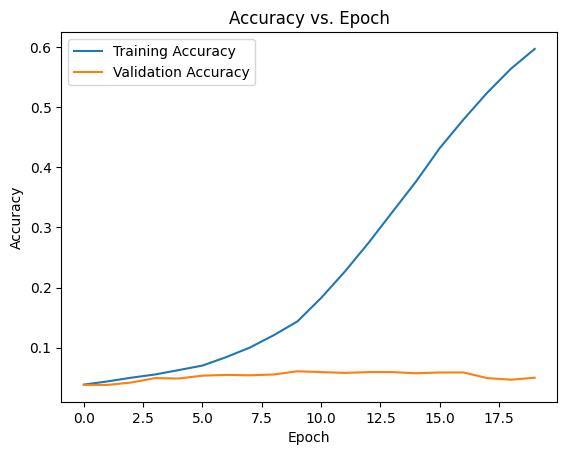

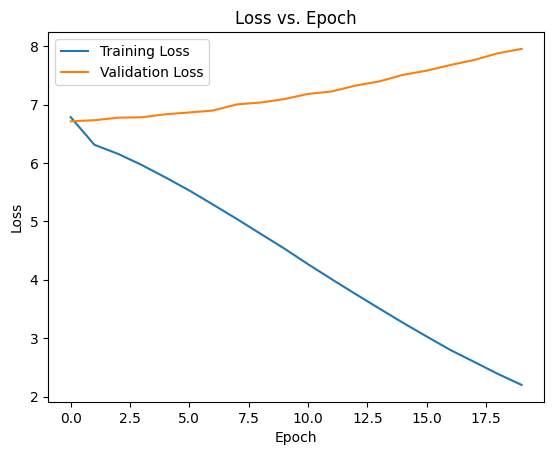

In [5]:
print("Roll No: 24BAD049")

import matplotlib.pyplot as plt

EPOCHS = 20
BATCH_SIZE = 64

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

train_acc = history.history["accuracy"][-1]
val_acc = history.history["val_accuracy"][-1]
train_loss = history.history["loss"][-1]
val_loss = history.history["val_loss"][-1]

print(f"Final Training Accuracy:   {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")
print(f"Final Training Loss:       {train_loss:.4f}")
print(f"Final Validation Loss:     {val_loss:.4f}")

plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Epoch")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs. Epoch")
plt.legend()
plt.show()

## Task D: Deep Learning Experiment Management (Text Generation)



In [6]:
print("Roll No: 24BAD049")

def generate_text(seed_text, next_words, model, tokenizer, max_input_len):
    """Repeatedly predict the next word to extend a seed word/sentence."""
    result = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=max_input_len, padding="pre")
        predicted_probs = model.predict(token_list, verbose=0)
        predicted_index = np.argmax(predicted_probs, axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break

        result += " " + output_word
    return result

seed_words = ["thou art", "to be or", "my lord"]
generated_samples = []

for seed in seed_words:
    generated = generate_text(seed, next_words=15, model=model, tokenizer=tokenizer, max_input_len=max_input_len)
    generated_samples.append(generated)
    print(f"Seed: \'{seed}\'")
    print(f"Generated: {generated}\n")

Roll No: 24BAD049
Seed: 'thou art'
Generated: thou art indifferently 'twixt doing them you are not after any reechy alias fools as an womb

Seed: 'to be or'
Generated: to be or being the senate who have the people than belly them deliberate put thee these base

Seed: 'my lord'
Generated: my lord up that baes like a lamb you less proud he is put my hour since

